# Using synthetic data generated from VAE-TIMEGAN

In [1]:
import pandas as pd
import numpy as np
import itertools
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import importlib
import my_lstm
importlib.reload(my_lstm)

from my_lstm import build_lstm_model, create_sequences, expanding_window_lstm_forecast

In [2]:
df = pd.read_csv('../data/final_data_with_VAETIMEGAN.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,AUD_USD_ret,CAD_USD_ret,NZD_USD_ret,ZAR_USD_ret,CPI,TB3MS,M1,M2,wti_ret
0,1958-03-01,0.012299,-0.002406,-0.006743,-0.023616,-0.005484,-0.073454,0.013188,0.008006,-0.203766
1,1958-04-01,0.020833,-0.009353,0.060724,0.005213,-0.003673,-0.079281,0.011769,0.009704,0.018075
2,1958-05-01,0.006006,-0.008792,0.009556,0.067115,0.002756,0.014742,0.017015,0.010501,0.180503
3,1958-06-01,-0.054147,0.010266,-0.037406,0.144931,0.003663,0.009709,0.013104,0.007785,-0.135577
4,1958-07-01,-0.090823,-0.006553,-0.026149,0.010176,0.000914,-0.063144,0.014577,0.008258,-0.147348


In [3]:
feature_cols = [
    "AUD_USD_ret",
    "CAD_USD_ret",
    "NZD_USD_ret",
    "ZAR_USD_ret",
    "CPI",
    "TB3MS",
    "M1",
    "M2", 
    "wti_ret"
]

target_col = "wti_ret"

In [4]:
df = df.sort_values("Date").reset_index(drop=True)

# compute indices based on original evaluation and test split
train_size = df.index[df["Date"] < "2014-02-01"][-1] + 1
val_end = df.index[df["Date"] <= "2020-01-01"][-1] + 1

# split using iloc 
train_data = df.iloc[:train_size]
val_data = df.iloc[train_size:val_end]
test_data = df.iloc[val_end:]

print(f"Train data length: {len(train_data)}")
print(f"Validation data length: {len(val_data)}")
print(f"Test data length: {len(test_data)}")

Train data length: 671
Validation data length: 72
Test data length: 72


In [5]:
# grid search over hyperparameters for the expanding window LSTM
param_grid_tiny = {
    "lookback": [2, 10],
    "dropout": [0.001, 0.1],
    "units": [50, 170],
    "epochs": [50, 100]
} 
param_combinations = list(itertools.product(
    param_grid_tiny["lookback"],
    param_grid_tiny["dropout"],
    param_grid_tiny["units"],
    param_grid_tiny["epochs"]
))

results_grid = []

for i, (lb, dr, units, ep) in enumerate(param_combinations, 1):
    print(f"\n[{i}/{len(param_combinations)}] Testing params:")
    print(f"lookback={lb}, dropout={dr}, units={units}, epochs={ep}")

    try:
        val_forecasts = expanding_window_lstm_forecast(
            df=df,
            feature_cols=feature_cols,
            target_col=target_col,
            initial_train_size=train_size,
            end_idx=val_end,
            date_col="Date",
            lookback=lb,
            units=units,
            dropout=dr,
            epochs=ep,
            batch_size=32,
            verbose=0,
            scale=True,
            seed=42
        )

        if len(val_forecasts) == 0:
            print("No forecasts generated, skipping.")
            continue

        mse = mean_squared_error(
            val_forecasts["actual"],
            val_forecasts["predicted"]
        )

        print(f"Validation MSE: {mse:.6f}")

        results_grid.append({
            "lookback": lb,
            "dropout": dr,
            "units": units,
            "epochs": ep,
            "mse": mse
        })

    except Exception as e:
        print(f"Error: {e}")
        continue



[1/16] Testing params:
lookback=2, dropout=0.001, units=50, epochs=50


2026-03-28 11:43:46.309718: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


Validation MSE: 0.589505

[2/16] Testing params:
lookback=2, dropout=0.001, units=50, epochs=100
Error: Graph execution error:

Detected at node 'mul_16' defined at (most recent call last):
    File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/traitlets/config/application.py", line 1075, in launch_instance
      app.start()
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/ipykernel/kernelapp.py", line 739, in start
      self.io_loop.start()
    File "/Users/jasonlow/Library/Python/3.10/lib/python/si

2026-03-28 14:21:30.279307: W tensorflow/core/framework/op_kernel.cc:1830] OP_REQUIRES failed at resource_variable_ops.cc:611 : INVALID_ARGUMENT: Cannot update variable with shape [1] using a Tensor with shape [0], shapes must be equal.


Error: Graph execution error:

Detected at node 'AssignSubVariableOp_7' defined at (most recent call last):
    File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/traitlets/config/application.py", line 1075, in launch_instance
      app.start()
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/ipykernel/kernelapp.py", line 739, in start
      self.io_loop.start()
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/tornado/platform/asyncio.py", line 205, in start
      self.asyncio_lo

In [6]:
results_grid

[{'lookback': 2,
  'dropout': 0.001,
  'units': 50,
  'epochs': 50,
  'mse': 0.5895047453848264},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 50,
  'epochs': 50,
  'mse': 0.46519655142281263},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 50,
  'epochs': 100,
  'mse': 0.7999130039637683},
 {'lookback': 10,
  'dropout': 0.001,
  'units': 50,
  'epochs': 100,
  'mse': 0.8817247900066391},
 {'lookback': 10,
  'dropout': 0.001,
  'units': 170,
  'epochs': 50,
  'mse': 0.5514468931222256},
 {'lookback': 10,
  'dropout': 0.1,
  'units': 50,
  'epochs': 50,
  'mse': 0.4229209421122668},
 {'lookback': 10,
  'dropout': 0.1,
  'units': 170,
  'epochs': 50,
  'mse': 0.5790714158203962},
 {'lookback': 10,
  'dropout': 0.1,
  'units': 170,
  'epochs': 100,
  'mse': 0.542189572919992}]

In [7]:
results_df = pd.DataFrame(results_grid)
results_df = results_df.sort_values("mse")

print(results_df.head())

best_params = results_df.iloc[0]
print(best_params)

   lookback  dropout  units  epochs       mse
5        10    0.100     50      50  0.422921
1         2    0.100     50      50  0.465197
7        10    0.100    170     100  0.542190
4        10    0.001    170      50  0.551447
6        10    0.100    170      50  0.579071
lookback    10.000000
dropout      0.100000
units       50.000000
epochs      50.000000
mse          0.422921
Name: 5, dtype: float64


# Out of sample testing

In [8]:
test_results = expanding_window_lstm_forecast(
    df=df,
    feature_cols=feature_cols,
    target_col=target_col,
    initial_train_size=val_end,  
    end_idx=len(df),    
    date_col="Date",        
    lookback=int(best_params["lookback"]),
    units=int(best_params["units"]),
    dropout=float(best_params["dropout"]),
    epochs=int(best_params["epochs"]),
    batch_size=32,
    verbose=0,
    scale=True,
    seed=42
)

test_mse = mean_squared_error(
    test_results["actual"],
    test_results["predicted"]
)

test_mape = mean_absolute_percentage_error(
    test_results["actual"],
    test_results["predicted"]
)

test_r2 = r2_score(
    test_results["actual"],
    test_results["predicted"]
)

print("Test MSE:", test_mse)
print("Test MAPE:", test_mape)
print("Test R²:", test_r2)


Test MSE: 0.6132805631543957
Test MAPE: 17.831719593122855
Test R²: -31.36648319023177


In [13]:
test_results.head()

,test_index,actual,predicted,Date
0,743,-0.129368,-0.264309,2020-02-01
1,744,-0.548254,-0.448555,2020-03-01
2,745,-0.568125,-3.489446,2020-04-01
3,746,0.545621,-1.181395,2020-05-01
4,747,0.293704,0.916706,2020-06-01


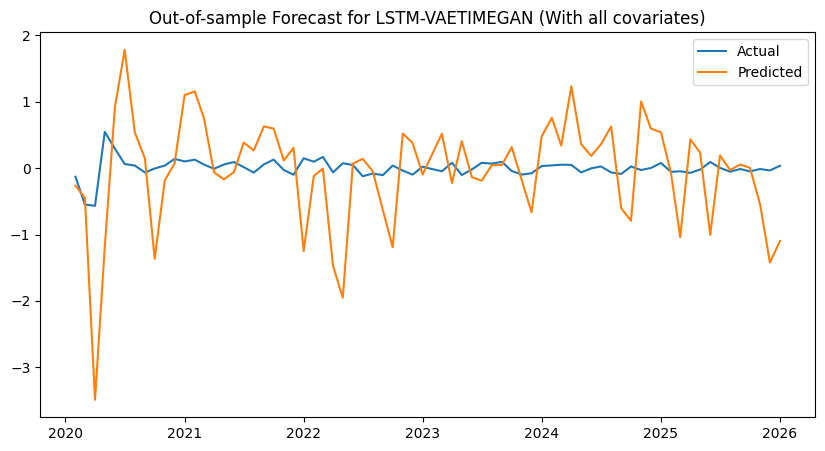

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test_results['Date'], test_results["actual"], label="Actual")
plt.plot(test_results['Date'], test_results["predicted"], label="Predicted")
plt.legend()
plt.title("Out-of-sample Forecast for LSTM-VAETIMEGAN (With all covariates)")
plt.show()

In [12]:
# save results to csv
test_results.to_csv('results/lstm-8-vaetimegan_results.csv', index = False)